In [1]:
#In this cell, all required Python libraries are imported.Pandas and NumPy are used for data manipulation and numerical operations.Matplotlib and Seaborn are used for data visualization.Scikit-learn provides machine learning models and evaluation metrics used throughout the project.
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

In [2]:
#This cell loads the preprocessed and scaled training and testing datasets.The datasets have already undergone cleaning, encoding, and feature scaling in the preprocessing stage.The shapes of the datasets are printed to verify successful loading and to confirm the number of samples and features.
train_df = pd.read_csv('train_data_scaled.xls')
test_df  = pd.read_csv('test_data_scaled.xls')

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (20000, 29)
Test shape: (5000, 29)


In [3]:
#Convert scaled target back to binary
#Positive = 1 (Good to live)
#Negative = 0 (Not good to live)

y_train = (train_df['is_good_to_live'] > 0).astype(int)
y_test  = (test_df['is_good_to_live'] > 0).astype(int)

In [4]:
#This cell removes features that directly or indirectly encode the target outcome. Variables such as flood risk scores and inundation metrics can cause data leakage, leading to unrealistically high model performance.Removing these features ensures that the models learn meaningful patterns rather than memorizing outcomes.
leakage_features = [
    'flood_risk_score',
    'flood_occurrence_current_event',
    'inundation_area_sqm',
    'reason_not_good_to_live',
    'is_synthetic'
]

X_train = train_df.drop(columns=['is_good_to_live'] + leakage_features)
X_test  = test_df.drop(columns=['is_good_to_live'] + leakage_features)

In [5]:
#The distribution of the target classes in the training dataset is examined.This step helps identify class imbalance, which is important for interpreting evaluation metrics such as accuracy and ROC-AUC.Understanding class proportions also informs future steps such as resampling or threshold tuning.print("Train target distribution:")
print(y_train.value_counts(normalize=True) * 100)

is_good_to_live
1    72.905
0    27.095
Name: proportion, dtype: float64


In [6]:
#A Logistic Regression model is trained as a baseline classifier. Logistic Regression is suitable for binary classification problems and provides probabilistic outputs. The model is trained using the cleaned feature set and the corrected binary target variable.
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

In [7]:
#A Decision Tree classifier is trained to capture non-linear relationships in the data. Depth and minimum split constraints are applied to reduce overfitting and improve generalization. Decision Trees also offer interpretability by modeling decisions as a series of logical splits.
dt = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=20,
    random_state=42
)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:, 1]

In [8]:
#A Random Forest classifier is trained as an ensemble model.It combines multiple decision trees to improve prediction stability and reduce variance. Parallel processing is enabled to improve training efficiency on larger datasets.
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

In [9]:
#This cell defines a reusable evaluation function to assess model performance.The function computes the confusion matrix, classification report, and ROC-AUC score.Using a common evaluation function ensures fair and consistent comparison across all models.
def evaluate_model(name, y_true, y_pred, y_prob):
    print(f"\n{name}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))
    print("ROC-AUC:", roc_auc_score(y_true, y_prob))

In [10]:
#All trained models are evaluated on the test dataset using the same metrics.Performance metrics are compared to assess each model’s ability to classify living suitability accurately.ROC-AUC is emphasized as it provides a threshold-independent measure of model performance.
evaluate_model("Logistic Regression", y_test, y_pred_lr, y_prob_lr)
evaluate_model("Decision Tree", y_test, y_pred_dt, y_prob_dt)
evaluate_model("Random Forest", y_test, y_pred_rf, y_prob_rf)


Logistic Regression
Confusion Matrix:
[[1080  329]
 [ 178 3413]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.77      0.81      1409
           1       0.91      0.95      0.93      3591

    accuracy                           0.90      5000
   macro avg       0.89      0.86      0.87      5000
weighted avg       0.90      0.90      0.90      5000

ROC-AUC: 0.9187911423539528

Decision Tree
Confusion Matrix:
[[1364   45]
 [  51 3540]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.97      0.97      1409
           1       0.99      0.99      0.99      3591

    accuracy                           0.98      5000
   macro avg       0.98      0.98      0.98      5000
weighted avg       0.98      0.98      0.98      5000

ROC-AUC: 0.9884940250634472

Random Forest
Confusion Matrix:
[[1325   84]
 [   3 3588]]

Classification Report:
              precision    recal

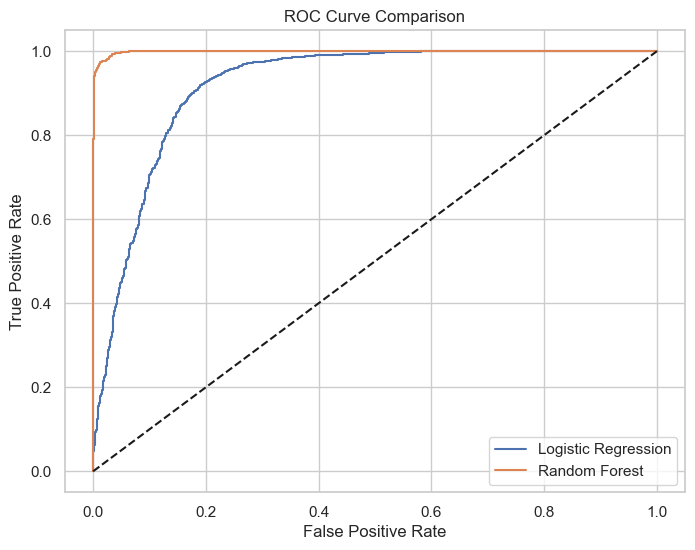

In [11]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(8,6))
plt.plot(fpr_lr, tpr_lr, label='Logistic Regression')
plt.plot(fpr_rf, tpr_rf, label='Random Forest')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

In [12]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'ROC-AUC': [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_dt),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

print(results)

                 Model   ROC-AUC
0  Logistic Regression  0.918791
1        Decision Tree  0.988494
2        Random Forest  0.998797


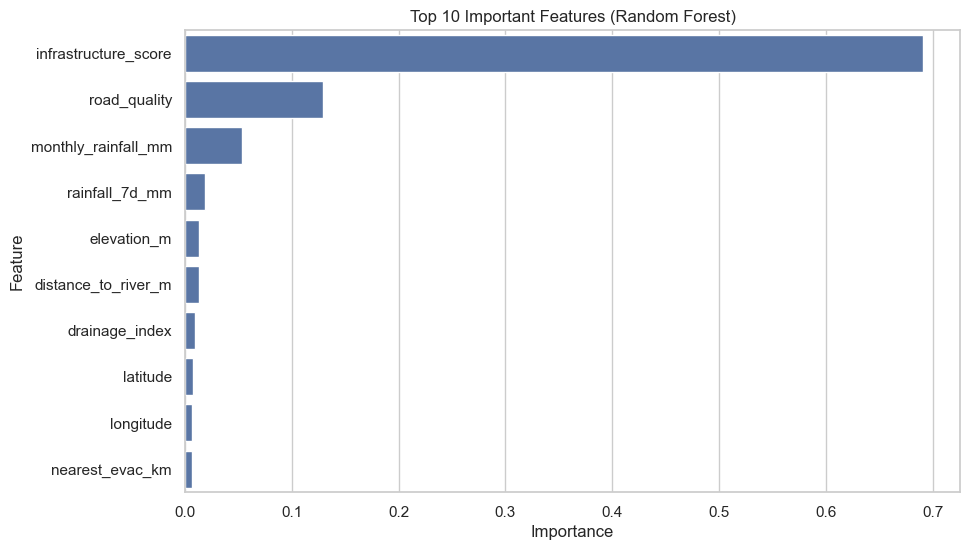

In [13]:
#Feature importance scores from the Random Forest model are visualized in this cell. The most influential features contributing to the classification decision are identified.This analysis provides insights into which environmental and infrastructural factors most affect living suitability.
importances = rf.feature_importances_
features = X_train.columns

feature_imp = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(
    data=feature_imp.head(10),
    x='Importance',
    y='Feature'
)
plt.title('Top 10 Important Features (Random Forest)')
plt.show()